In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud

np.random.seed(42)


In [3]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Book_review.csv to Book_review.csv


**DATASET LOADING**

In [5]:
df_raw = pd.read_csv('Book_review.csv')
print("Original shape:", df_raw.shape)
print("Original columns:", df_raw.columns.tolist())

# Drop accidental index columns commonly saved by pandas, e.g. "Unnamed: 0".
unnamed_cols = [col for col in df_raw.columns if col.lower().startswith('unnamed')]
if unnamed_cols:
    print("Dropping unnecessary Unnamed columns:", unnamed_cols)
    df_raw = df_raw.drop(columns=unnamed_cols)
else:
    print("No Unnamed columns found.")

required_cols = ['reviewText', 'rating']
print("Missing values before cleaning:")
print(df_raw[required_cols].isna().sum())

df = df_raw[required_cols].copy()
df = df.dropna(subset=required_cols)
df['reviewText'] = df['reviewText'].astype(str).str.strip()
df = df[df['reviewText'] != '']

def convert_sentiment(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df['sentiment'] = df['rating'].apply(convert_sentiment).astype(int)
df = df.rename(columns={'reviewText': 'review'})

label_names = ['Negative', 'Neutral', 'Positive']
print("Final shape after missing-value cleaning:", df.shape)
print("Class distribution:")
print(df['sentiment'].value_counts().sort_index().rename(index=dict(enumerate(label_names))))

df.head()


Original shape: (12000, 4)
Original columns: ['Unnamed: 0', 'rating', 'reviewText', 'summary']
Dropping unnecessary Unnamed columns: ['Unnamed: 0']
Missing values before cleaning:
reviewText    0
rating        0
dtype: int64
Final shape after missing-value cleaning: (12000, 3)
Class distribution:
sentiment
Negative    4000
Neutral     2000
Positive    6000
Name: count, dtype: int64


,review,rating,sentiment
0,This book was the very first bookmobile book I...,5,2
1,"When I read the description for this book, I c...",1,0
2,I just had to edit this review. This book is a...,5,2
3,I don't normally buy 'mystery' novels because ...,5,2
4,"This isn't the kind of book I normally read, a...",5,2


The rating column is converted into three sentiment classes: ratings 1-2 are Negative, rating 3 is Neutral, and ratings 4-5 are Positive. This preserves the full meaning of the rating scale and keeps the task aligned with a multiclass sentiment analysis setting.


**TEXT CLEANING**

In [6]:
def expand_contractions(text):
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "can't": "cannot", "couldn't": "could not", "won't": "will not",
        "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
        "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
        "you're": "you are", "you've": "you have", "you'll": "you will",
        "it's": "it is", "that's": "that is", "there's": "there is",
        "what's": "what is", "they're": "they are", "we're": "we are"
    }
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text):
    text = text.lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor', 'never', 'cannot'}
stop_words = stop_words - negation_words

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['clean'] = df['review'].apply(clean_text).apply(preprocess_text)
df = df[df['clean'].str.strip() != ''].copy()

print("Rows after text cleaning:", df.shape[0])
print("Negation words kept during stopword removal:", sorted(negation_words))
df[['review', 'clean', 'sentiment']].head()


Rows after text cleaning: 12000
Negation words kept during stopword removal: ['cannot', 'never', 'no', 'nor', 'not']


,review,clean,sentiment
0,This book was the very first bookmobile book I...,book first bookmobile book bought school book ...,2
1,"When I read the description for this book, I c...",read description book could not wait read down...,0
2,I just had to edit this review. This book is a...,edit review book believe got right updated wri...,2
3,I don't normally buy 'mystery' novels because ...,not normally buy mystery novel not like howeve...,2
4,"This isn't the kind of book I normally read, a...",not kind book normally read although try not l...,2


**WORDCLOUD**

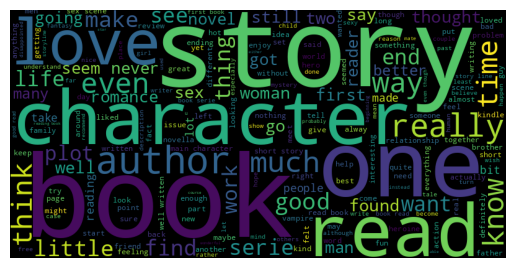

In [7]:
text = " ".join(df['clean'])
wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

**MOST FREQUENT WORDS**


         word  frequency
0         not      19799
1        book      15920
2       story      11491
3        read       8279
4         one       6175
5   character       5849
6        like       5248
7       would       4935
8        good       4392
9        love       3890
10     really       3887
11       time       3737
12        get       3599
13     author       3575
14         no       3039
15      could       3030
16     series       2950
17       well       2904
18    reading       2878
19       much       2737


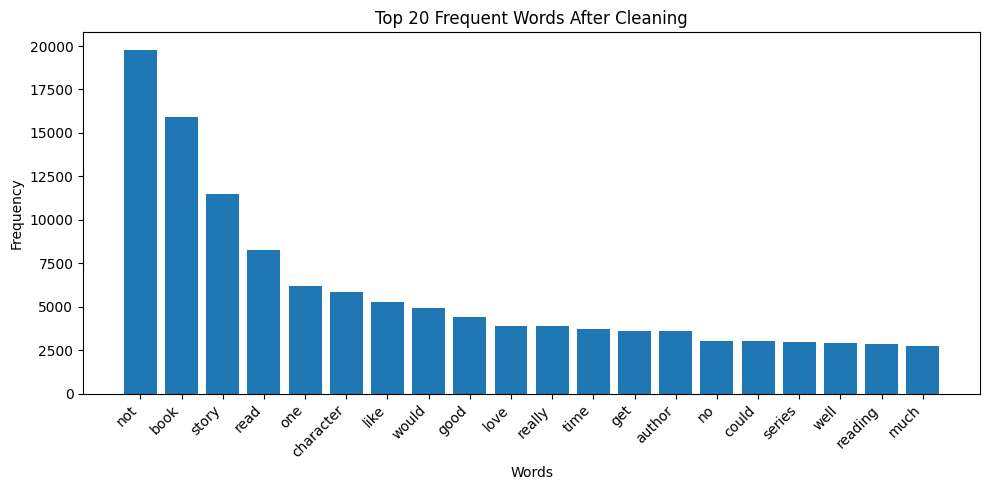

In [8]:
all_words = " ".join(df['clean']).split()
word_freq = Counter(all_words)
common_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'frequency'])
print(common_words)

plt.figure(figsize=(10, 5))
plt.bar(common_words['word'], common_words['frequency'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Frequent Words After Cleaning')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**TOKENIZATION + SPLIT**

In [9]:
X = df['clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

sequence_lengths = [len(seq) for seq in X_train_seq]
max_len = max(1, int(np.percentile(sequence_lengths, 95)))

# Pre-padding works better with standard RNN/LSTM layers because the final time steps
# contain real words instead of long runs of padding zeros.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='pre', truncating='pre')

vocab_size = len(tokenizer.word_index) + 1
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(zip(np.unique(y_train), class_weights_array))

print("Training samples:", X_train_pad.shape[0])
print("Testing samples:", X_test_pad.shape[0])
print("95th percentile max length:", max_len)
print("Vocabulary size:", vocab_size)
print("Class weights:", class_weight)


Training samples: 9600
Testing samples: 2400
95th percentile max length: 186
Vocabulary size: 24111
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(2.0), np.int64(2): np.float64(0.6666666666666666)}


Class weights are used because the dataset is imbalanced: Positive reviews are the largest class and Neutral reviews are the smallest class. Without class weights, the model can get about 50% accuracy by predicting mostly Positive, which is not a useful classifier. Pre-padding is also used so the final RNN/LSTM time steps contain real words rather than padding tokens.


**CALLBACK**

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

**MODEL 1 (RNN)**

In [11]:
model1 = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])

model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history1 = model1.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5297 - loss: 0.9936 - val_accuracy: 0.6458 - val_loss: 0.8024
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8407 - loss: 0.4677 - val_accuracy: 0.6171 - val_loss: 0.8940
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9736 - loss: 0.0942 - val_accuracy: 0.6292 - val_loss: 1.0879
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9964 - loss: 0.0193 - val_accuracy: 0.6438 - val_loss: 1.1957


**MODEL 2 (LSTM)**

In [12]:
model2 = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(3, activation='softmax')
])

model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history2 = model2.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.6626 - loss: 0.8653 - val_accuracy: 0.6554 - val_loss: 0.7693
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7928 - loss: 0.5628 - val_accuracy: 0.7000 - val_loss: 0.7296
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8761 - loss: 0.3470 - val_accuracy: 0.6621 - val_loss: 0.8521
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9257 - loss: 0.2164 - val_accuracy: 0.6929 - val_loss: 0.9371
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9615 - loss: 0.1285 - val_accuracy: 0.6662 - val_loss: 1.1827


**EVALUATION**

In [13]:
test_accuracies = {}

def evaluate_model(model, name):
    y_prob = model.predict(X_test_pad, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    accuracy = accuracy_score(y_test, y_pred)
    test_accuracies[name] = accuracy
    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))
    return y_pred

y_pred_rnn = evaluate_model(model1, 'RNN')
y_pred_lstm = evaluate_model(model2, 'LSTM')



RNN Accuracy: 0.6458
Confusion Matrix:
[[560 170  70]
 [134 110 156]
 [137 183 880]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.70      0.69       800
     Neutral       0.24      0.28      0.25       400
    Positive       0.80      0.73      0.76      1200

    accuracy                           0.65      2400
   macro avg       0.57      0.57      0.57      2400
weighted avg       0.66      0.65      0.65      2400


LSTM Accuracy: 0.7000
Confusion Matrix:
[[614 146  40]
 [121 181  98]
 [ 66 249 885]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       800
     Neutral       0.31      0.45      0.37       400
    Positive       0.87      0.74      0.80      1200

    accuracy                           0.70      2400
   macro avg       0.65      0.65      0.64      2400
weighted avg       0.74      0.70      0.72      2400



In [14]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.0 MB/s eta 0:00:00


**MODEL 3 (PRETRAINED EMBEDDING LSTM)**


In [15]:
import gensim.downloader as api

# Strict assignment requirement: use pretrained Word2Vec embeddings.
# This downloads the Google News Word2Vec vectors and may take time in Colab.
# If your environment cannot handle it, you can temporarily switch to
# 'glove-wiki-gigaword-100', but mention that as a fallback in your viva/report.
pretrained_model_name = 'word2vec-google-news-300'
pretrained_vectors = api.load(pretrained_model_name)
embedding_dim = pretrained_vectors.vector_size

embedding_matrix = np.zeros((vocab_size, embedding_dim))
matched_words = 0
for word, i in tokenizer.word_index.items():
    if word in pretrained_vectors:
        embedding_matrix[i] = pretrained_vectors[word]
        matched_words += 1

print(f"Loaded pretrained embeddings: {pretrained_model_name}")
print(f"Embedding dimension: {embedding_dim}")
print(f"Matched vocabulary words: {matched_words} / {vocab_size - 1}")

model3 = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=False),
    LSTM(64),
    Dense(3, activation='softmax')
])

model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history3 = model3.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight
)


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Loaded pretrained embeddings: word2vec-google-news-300
Embedding dimension: 300
Matched vocabulary words: 19749 / 24110


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6308 - loss: 0.8897 - val_accuracy: 0.6342 - val_loss: 0.8160
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6709 - loss: 0.7971 - val_accuracy: 0.6787 - val_loss: 0.7204
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6922 - loss: 0.7537 - val_accuracy: 0.7212 - val_loss: 0.6813
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7038 - loss: 0.7256 - val_accuracy: 0.6817 - val_loss: 0.7175
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7215 - loss: 0.6900 - val_accuracy: 0.6092 - val_loss: 0.7960
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7334 - loss: 0.6579 - val_accuracy: 0.7092 - val_loss: 0.6809
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7558 - loss: 0.6147 - val_accuracy: 0.6671 - val_loss: 0.7467
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7741 - loss: 0.5707 - val_acc

**MODEL 3 EVALUATION**


In [23]:
y_pred_w2v_lstm = evaluate_model(model3, 'Pretrained Word2Vec LSTM')



Pretrained Word2Vec LSTM Accuracy: 0.7092
Confusion Matrix:
[[ 553  139  108]
 [  97  137  166]
 [  49  139 1012]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.69      0.74       800
     Neutral       0.33      0.34      0.34       400
    Positive       0.79      0.84      0.81      1200

    accuracy                           0.71      2400
   macro avg       0.64      0.63      0.63      2400
weighted avg       0.71      0.71      0.71      2400



**ERROR ANALYSIS**


In [17]:
best_model_name = max(test_accuracies, key=test_accuracies.get)
best_predictions = {
    'RNN': y_pred_rnn,
    'LSTM': y_pred_lstm,
    'Pretrained Word2Vec LSTM': y_pred_w2v_lstm
}[best_model_name]

error_df = pd.DataFrame({
    'review': df.loc[X_test.index, 'review'],
    'clean_text': X_test,
    'actual': y_test.astype(int),
    'predicted': best_predictions.astype(int)
})

misclassified_examples = error_df[error_df['actual'] != error_df['predicted']].head(3)
print("Best model used for error analysis:", best_model_name)
print("Number of misclassified test examples:", len(error_df[error_df['actual'] != error_df['predicted']]))

for idx, row in misclassified_examples.iterrows():
    print("\nReview:", row['review'][:500])
    print("Actual sentiment:", label_names[row['actual']])
    print("Predicted sentiment:", label_names[row['predicted']])


Best model used for error analysis: Pretrained Word2Vec LSTM
Number of misclassified test examples: 698

Review: Just an awesome kilndle paper. The content cannot be beaten. Great writing and all around coverage of the news. Just way too costly at $20.00 per month. $5 more than the next costliest paper. I wanted to continue my subscription but there are way too many other papers out there from $6 to $10 per month. Would give it 5 stars but for the cost.
Actual sentiment: Positive
Predicted sentiment: Neutral

Review: I thought with all the positive reviews I would love this book.  Not! This book is horrible it starts fast (literally she is in love with one man in the morning and in love with another by the evening) and the premise of indecent proposal wasn't even done well.  The heroine I'm sorry I found her stupid and greedy.  She was the worst that you would think of someone from the country just ignorant she made us look bad.  So glad I haven't  spent the $5.99 a piece for the other

Possible reasons for errors:
- Neutral reviews can be difficult because they often contain both positive and negative opinions.
- Short reviews or reviews with mixed opinions can lose important context during cleaning.
- Sarcasm, negation, and domain-specific book-review phrases may be difficult for simple RNN/LSTM models.
- Removing stopwords can sometimes remove useful sentiment cues such as negation.
- The pretrained Word2Vec model may not contain every book-specific word from the dataset.

Potential improvements:
- Keep important negation words such as not, no, and never during preprocessing.
- Tune sequence length, embedding dimension, LSTM units, dropout, batch size, and learning rate.
- Use bidirectional LSTM/GRU or transformer-based models for stronger contextual understanding.
- Handle class imbalance using class weights or resampling if one class has much fewer examples.


**TRAINING vs VALIDATION**

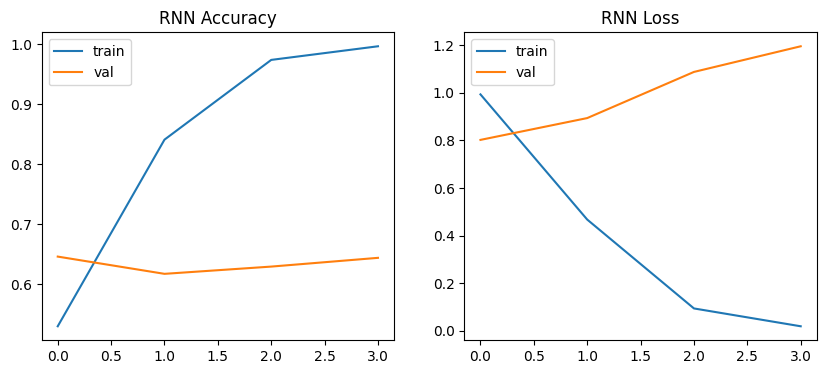

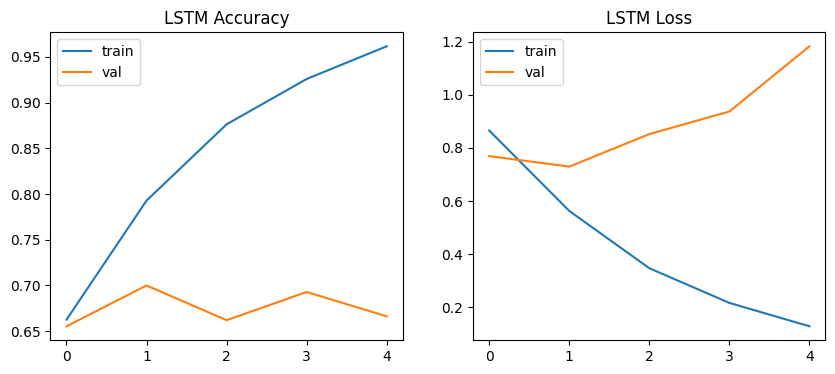

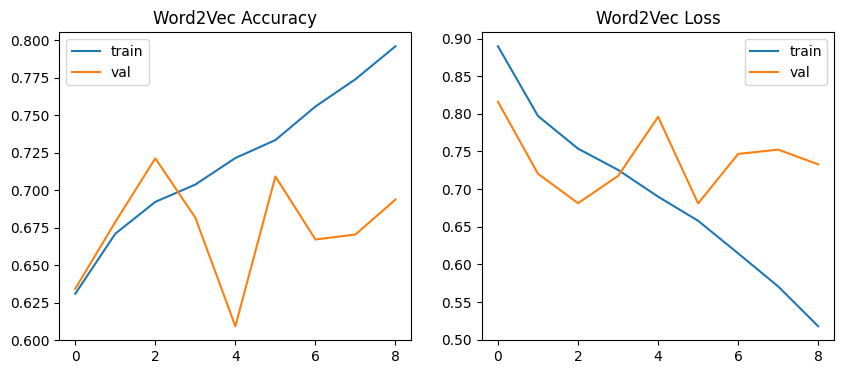

In [18]:
def plot_full(history, title):
    plt.figure(figsize=(10,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_full(history1, "RNN")
plot_full(history2, "LSTM")
plot_full(history3, "Word2Vec")

**COMPARISON GRAPH**

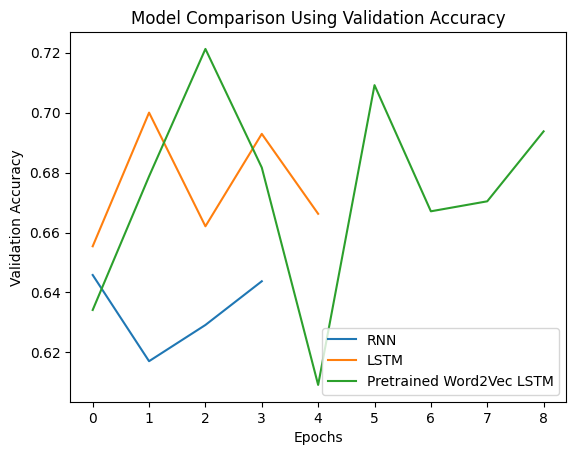

,Model,Test Accuracy
2,Pretrained Word2Vec LSTM,0.709167
1,LSTM,0.700000
0,RNN,0.645833


In [19]:
plt.plot(history1.history['val_accuracy'], label='RNN')
plt.plot(history2.history['val_accuracy'], label='LSTM')
plt.plot(history3.history['val_accuracy'], label='Pretrained Word2Vec LSTM')

plt.title("Model Comparison Using Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

pd.DataFrame({
    'Model': list(test_accuracies.keys()),
    'Test Accuracy': list(test_accuracies.values())
}).sort_values('Test Accuracy', ascending=False)


**MODEL COMPLEXITY vs PERFORMANCE**

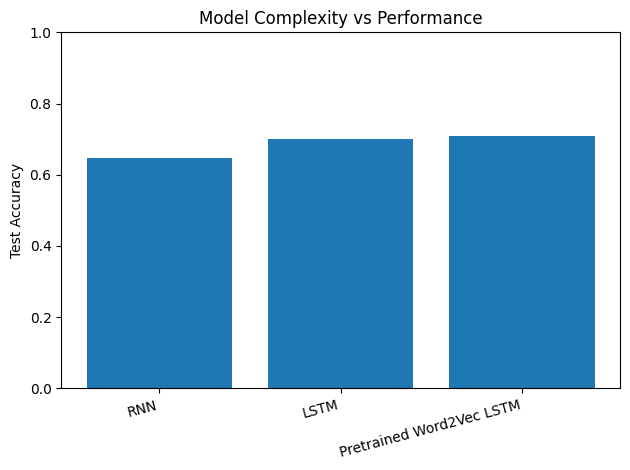

RNN is the simplest model, LSTM adds gating for longer dependencies, and the pretrained embedding LSTM adds external semantic knowledge through the embedding matrix.


In [20]:
model_names = list(test_accuracies.keys())
accuracies = list(test_accuracies.values())

plt.bar(model_names, accuracies)
plt.title("Model Complexity vs Performance")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("RNN is the simplest model, LSTM adds gating for longer dependencies, and the pretrained embedding LSTM adds external semantic knowledge through the embedding matrix.")


**OPTIONAL GUI FOR REAL-TIME PREDICTION**


In [21]:
!pip install gradio -q

In [22]:
import gradio as gr

final_models = {
    'Simple RNN': model1,
    'LSTM Trainable': model2,
    'LSTM + Word2Vec': model3
}

def predict_sentiment(review_text):
    if not review_text.strip():
        return 'Please enter a review.'

    cleaned = preprocess_text(clean_text(review_text))
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='pre', truncating='pre')

    output_lines = [
        f'Cleaned text:\n{cleaned[:200]}...\n',
        '-' * 65
    ]

    for model_name, model in final_models.items():
        probabilities = model.predict(padded, verbose=0)[0]
        predicted_index = int(np.argmax(probabilities))
        predicted_label = label_names[predicted_index]
        confidence = probabilities[predicted_index] * 100
        output_lines.append(
            f'{model_name:<22} -> {predicted_label:<10} '
            f'(Neg: {probabilities[0]:.2f}, Neu: {probabilities[1]:.2f}, '
            f'Pos: {probabilities[2]:.2f}, Conf: {confidence:.1f}%)'
        )

    output_lines.append('-' * 65)
    return '\n'.join(output_lines)

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=6,
        placeholder='Enter your book review here...',
        label='Book Review'
    ),
    outputs=gr.Textbox(
        label='Sentiment Predictions - All 3 Models',
        lines=10
    ),
    title='Book Review Sentiment Classifier',
    description='Enter a book review to get Negative, Neutral, or Positive sentiment from all 3 models.',
    examples=[
        ['This book was absolutely amazing! Could not put it down!'],
        ['Very disappointed. The plot was confusing. Waste of money.'],
        ['It was an okay read. Nothing special but not terrible either.'],
        ['Started slow but the ending completely redeemed it.']
    ]
)

In [24]:
demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://18945a8136a318f85f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://18945a8136a318f85f.gradio.live
